In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Commented out as no need to do more rezipping


In [ ]:
# base_path = "/content/drive/MyDrive/BRATS_FINAL_ML_PROJECT"

# !unzip -q "{base_path}/BraTS2024-BraTS-GLI-TrainingData.zip" -d "{base_path}/BraTS2024-BraTS-GLI-TrainingData"
# !unzip -q "{base_path}/BraTS2024-BraTS-GLI-ValidationData.zip" -d "{base_path}/BraTS2024-BraTS-GLI-ValidationData"
# !unzip -q "{base_path}/BraTS2024-BraTS-GLI-AdditionalTrainingData.zip" -d "{base_path}/BraTS2024-BraTS-GLI-AdditionalTrainingData"


Cell 2 – Install packages & imports

In [ ]:
!pip install -q nibabel tqdm

import os, glob, random
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from tqdm import tqdm #??? eror when thi is msising?
import shutil




!mkdir -p /content/local_data


print("copying data from Drive to local disk...")


!cp -r "/content/drive/MyDrive/BRATS_FINAL_ML_PROJECT/BraTS2024-BraTS-GLI-TrainingData" /content/local_data/


!cp -r "/content/drive/MyDrive/BRATS_FINAL_ML_PROJECT/BraTS2024-BraTS-GLI-AdditionalTrainingData" /content/local_data/

print("fiinished copying")

base_path = "/content/local_data"


train_root = os.path.join(base_path, "BraTS2024-BraTS-GLI-TrainingData")
add_train_root = os.path.join(base_path, "BraTS2024-BraTS-GLI-AdditionalTrainingData")
#



def get_case_dirs(*roots):

    case_dirs = []
    for r in roots:
        if not os.path.exists(r):
            continue
        for d in glob.glob(os.path.join(r, "**", "BraTS-GLI-*"), recursive=True):
            if os.path.isdir(d):
                case_dirs.append(d)
    case_dirs = sorted(set(case_dirs))
    print(f"found {len(case_dirs)} cases")
    return case_dirs

all_case_dirs = get_case_dirs(train_root, add_train_root)



copying data from Drive to local disk...
fiinished copying
found 1621 cases


Cell 3 – Dataset & simple augmentations

In [ ]:


class RandomFlipRotate2D:
    """
    augmentation for 2D slices.
    - has horizontal and vertical flips
    - 180 rotation
    """

    def __init__(self, p_flip=0.5, p_rot180=0.5):
        self.p_flip = p_flip
        self.p_rot180 = p_rot180

    def __call__(self, image, mask):

        # horizontal flip
        if np.random.rand() < self.p_flip:
            image = np.flip(image, axis=2)
            mask = np.flip(mask, axis=1)

        # vertical flip
        if np.random.rand() < self.p_flip:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=0)

        # 180 rotation
        if np.random.rand() < self.p_rot180:
            image = np.rot90(image, k=2, axes=(1, 2))
            mask = np.rot90(mask,  k=2, axes=(0, 1))

        image = np.ascontiguousarray(image)
        mask = np.ascontiguousarray(mask)
        return image, mask


class BraTS2024SliceDataset(Dataset):
    """
    slice dataset for BraTS 2024 GLI
      - plan: limit subset of slices per case
      - pads slices to common target size so stack is possible for dataloader
    """

    def __init__(
        self,
        case_dirs,
        modalities,
        tumor_only=True,
        transform=None,
        target_size=None,
        max_slices_per_case=None
    ):
        super().__init__()
        self.case_dirs = list(case_dirs)
        self.modalities = modalities
        self.tumor_only = tumor_only
        self.transform = transform
        self.max_slices_per_case = max_slices_per_case

        self.samples = []
        self._cache = {}

        self.max_H = 0
        self.max_W = 0

        self._build_index()

        if target_size is None:
            self.target_size = (self.max_H, self.max_W)
        else:
            self.target_size = target_size

        print(f"Dataset target size (H, W): {self.target_size}")

    def _build_index(self):
        print("Building slice index...")
        for case_dir in tqdm(self.case_dirs, desc="Indexing cases"):
            seg_paths = glob.glob(os.path.join(case_dir, "*seg.nii*"))
            if len(seg_paths) == 0:
                continue

            seg_path = seg_paths[0]
            seg = nib.load(seg_path).get_fdata().astype(np.int16)

            H, W, D = seg.shape
            self.max_H = max(self.max_H, H)
            self.max_W = max(self.max_W, W)

            slice_indices = list(range(D))
            if self.tumor_only:
                slice_indices = [z for z in slice_indices if np.max(seg[:, :, z]) > 0]

            if self.max_slices_per_case is not None and len(slice_indices) > self.max_slices_per_case:
                slice_indices = random.sample(slice_indices, self.max_slices_per_case)

            for z in slice_indices:
                self.samples.append((case_dir, z))

        print(f"Total slices: {len(self.samples)}")
        print(f"Max H: {self.max_H}, Max W: {self.max_W}")

    def _load_case(self, case_dir):
        """
        loads segs and modalities for case
        output:
          image_vol: [C, H, W, D]
          seg_vol:   [H, W, D]
        """
        if case_dir in self._cache:
            return self._cache[case_dir]

        vols = []
        for mod in self.modalities:
            mod_paths = glob.glob(os.path.join(case_dir, f"*{mod}.nii*"))
            if len(mod_paths) == 0:
                raise FileNotFoundError(f"where da modality at??? '{mod}' in {case_dir}")
            mod_path = mod_paths[0]

            arr = nib.load(mod_path).get_fdata().astype(np.float32)
            nonzero = arr[arr > 0]
            if nonzero.size > 0:
                m = nonzero.mean()
                s = nonzero.std() + 1e-8
                arr = (arr - m) / s

            vols.append(arr)

        image_vol = np.stack(vols, axis=0)

        seg_paths = glob.glob(os.path.join(case_dir, "*seg.nii*"))
        if len(seg_paths) == 0:
            raise FileNotFoundError(f"no seg.nii found in {case_dir}")
        seg_vol = nib.load(seg_paths[0]).get_fdata().astype(np.int16)

        self._cache[case_dir] = (image_vol, seg_vol)
        return image_vol, seg_vol

    def _pad_to_target(self, img_slice, mask_slice):
        """
        pad image and mask to target size
        [C,H,W] and [H,W] -> (H,W)
        """
        target_H, target_W = self.target_size
        C, H, W = img_slice.shape

        pad_H = target_H - H
        pad_W = target_W - W

        assert pad_H >= 0 and pad_W >= 0, "error, target size < slice sizeTarget..have to check this due earlier colab bug"

        pad_img = (
            (0, 0),
            (pad_H // 2, pad_H - pad_H // 2),
            (pad_W // 2, pad_W - pad_W // 2),
        )
        pad_mask = (
            (pad_H // 2, pad_H - pad_H // 2),
            (pad_W // 2, pad_W - pad_W // 2),
        )

        img_slice_padded = np.pad(img_slice, pad_img, mode="constant", constant_values=0)
        mask_slice_padded = np.pad(mask_slice, pad_mask, mode="constant", constant_values=0)

        return img_slice_padded, mask_slice_padded

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        case_dir, z = self.samples[idx]
        image_vol, seg_vol = self._load_case(case_dir)

        img_slice = image_vol[:, :, :, z]
        mask_slice = seg_vol[:, :, z]

        img_slice = img_slice.astype(np.float32)
        mask_slice = mask_slice.astype(np.int64)

        if self.transform is not None:
            img_slice, mask_slice = self.transform(img_slice, mask_slice)

        img_slice, mask_slice = self._pad_to_target(img_slice, mask_slice)

        img_tensor = torch.from_numpy(img_slice).float()
        mask_tensor = torch.from_numpy(mask_slice).long()
        return img_tensor, mask_tensor


Cell 4 – Create DataLoaders

In [ ]:
from torch.utils.data import DataLoader

MODALITIES = ("t1n", "t1c", "t2w", "t2f")
NUM_CLASSES = 5                             # 0 background is one as well

max_cases = 200    # tweaked at 100,150,200, more later if possible

random.seed(37)
cases = all_case_dirs[:]
random.shuffle(cases)
cases = cases[:max_cases]


split_idx = int(0.8 * len(cases))
train_cases = cases[:split_idx]
val_cases   = cases[split_idx:]

print(f"Total cases used: {len(cases)}")
print(f"Train cases: {len(train_cases)}, Val cases: {len(val_cases)}")

max_slices_train = 20   # 20 tumor slices per train case
max_slices_val   = 20

train_transform = RandomFlipRotate2D(p_flip=0.5, p_rot180=0.5)

train_dataset = BraTS2024SliceDataset(
    case_dirs=train_cases,
    modalities=MODALITIES,
    tumor_only=True,                  # only tumor slices fix the other bug for tumor slice cuz it wasn't choosing the right cases..
    transform=train_transform,
    max_slices_per_case=max_slices_train,
)

val_dataset = BraTS2024SliceDataset(
    case_dirs=val_cases,
    modalities=MODALITIES,
    tumor_only=False,
    transform=None,
    max_slices_per_case=max_slices_val,
)

BATCH_SIZE = 4
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train slices:", len(train_dataset))
print("Val slices:", len(val_dataset))

imgs, masks = next(iter(train_loader))
print("Batch image shape:", imgs.shape)
print("Batch mask shape:", masks.shape)


Total cases used: 200
Train cases: 160, Val cases: 40
Building slice index...


Indexing cases: 100%|██████████| 160/160 [00:24<00:00,  6.50it/s]


Total slices: 3199
Max H: 182, Max W: 218
Dataset target size (H, W): (182, 218)
Building slice index...


Indexing cases: 100%|██████████| 40/40 [00:05<00:00,  6.77it/s]


Total slices: 800
Max H: 182, Max W: 218
Dataset target size (H, W): (182, 218)
Train slices: 3199
Val slices: 800
Batch image shape: torch.Size([4, 4, 182, 218])
Batch mask shape: torch.Size([4, 182, 218])


Cell 5 – Invariant U‑Net model + loss + metrics

In [ ]:
class GroupInvariantConv2d(nn.Module):
    """
    Rotation + flip invariant convolution
    does conv2d on transformed copy of input and averages inverse transformed output
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dilation: int = 1,
        groups: int = 1,
        bias: bool = True,
        use_flips: bool = True,
    ):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            dilation=dilation,
            groups=groups,
            bias=bias,
        )
        self.use_flips = use_flips

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        [B, C, H, W] --》 [B, Cout, H, W]
        invariant to 90° rotations and flipping
        """
        outputs = []

        for k in range(4):
            # rotate input
            x_rot = torch.rot90(x, k=k, dims=(2, 3))
            # conv on rotated
            y_rot = self.conv(x_rot)
            # inverse rotation
            y_rot_inv = torch.rot90(y_rot, k=-k, dims=(2, 3))
            outputs.append(y_rot_inv)

            if self.use_flips:
                x_rf = torch.flip(x_rot, dims=(3,))  # horizontal flip
                y_rf = self.conv(x_rf)
                y_rf_inv = torch.flip(torch.rot90(y_rf, k=-k, dims=(2, 3)), dims=(3,))
                outputs.append(y_rf_inv)

        out = torch.stack(outputs, dim=0).mean(dim=0)
        return out


class DoubleConvInvariant(nn.Module):
    """
    Two group invariant convs with BatchNorm + ReLU
    """

    def __init__(self, in_channels: int, out_channels: int, mid_channels: int | None = None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.conv1 = GroupInvariantConv2d(in_channels, mid_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(mid_channels)
        self.conv2 = GroupInvariantConv2d(mid_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x, inplace=True)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x, inplace=True)
        return x


class Down(nn.Module):
    #Downscaling with maxpool then invariant double conv

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConvInvariant(in_channels, out_channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(x)
        x = self.conv(x)
        return x


class Up(nn.Module):
    #Upscaling then invariant double conv

    def __init__(self, in_channels: int, out_channels: int, bilinear: bool = True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConvInvariant(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels // 2, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConvInvariant(in_channels, out_channels)

    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        x1 = self.up(x1)

        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2,
             diff_y // 2, diff_y - diff_y // 2],
        )

        x = torch.cat([x2, x1], dim=1)
        x = self.conv(x)
        return x


class OutConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class InvariantUNet(nn.Module):

    #U Net architecture...group invariant conv blocks


    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        base_channels: int = 32,
        bilinear: bool = True,
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.bilinear = bilinear

        self.inc = DoubleConvInvariant(in_channels, base_channels)
        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_channels * 8, base_channels * 16 // factor)

        self.up1 = Up(base_channels * 16, base_channels * 8 // factor, bilinear)
        self.up2 = Up(base_channels * 8, base_channels * 4 // factor, bilinear)
        self.up3 = Up(base_channels * 4, base_channels * 2 // factor, bilinear)
        self.up4 = Up(base_channels * 2, base_channels, bilinear)
        self.outc = OutConv(base_channels, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits


def multiclass_dice_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    smooth: float = 1e-5,
    ignore_index: int | None = None,
    include_background: bool = True,
) -> torch.Tensor:

    """
    Soft Dice loss for multi class segmentation
    """
    num_classes = logits.size(1)
    probs = F.softmax(logits, dim=1)

    t = targets.clone()
    if ignore_index is not None:
        t[t == ignore_index] = 0

    target_one_hot = F.one_hot(t.long(), num_classes=num_classes)
    target_one_hot = target_one_hot.permute(0, 3, 1, 2).float()

    if ignore_index is not None:
        mask = (targets != ignore_index).unsqueeze(1)
        probs = probs * mask
        target_one_hot = target_one_hot * mask

    if not include_background and num_classes > 1:
        probs = probs[:, 1:]
        target_one_hot = target_one_hot[:, 1:]

    dims = (0, 2, 3)
    intersection = (probs * target_one_hot).sum(dims)
    cardinality = (probs + target_one_hot).sum(dims)

    dice = (2.0 * intersection + smooth) / (cardinality + smooth)
    loss = 1.0 - dice.mean()
    return loss


class DiceCELoss(nn.Module):

    #CrossEntropy + soft Dice loss.


    def __init__(
        self,
        dice_weight: float = 1.0,
        ce_weight: float = 1.0,
        ignore_index: int | None = None,
        include_background_in_dice: bool = True,
    ):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.ignore_index = ignore_index
        self.include_background_in_dice = include_background_in_dice

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets.long(), ignore_index=self.ignore_index)
        dice = multiclass_dice_loss(
            logits,
            targets,
            ignore_index=self.ignore_index,
            include_background=self.include_background_in_dice,
        )
        return self.ce_weight * ce + self.dice_weight * dice


def multiclass_dice_score(
    logits: torch.Tensor,
    targets: torch.Tensor,
    ignore_index: int | None = None,
) -> dict:
    """
    Computes Dice score of the classes
    outputing -> {class_idx: dice, 'mean': macro_mean}
    """
    with torch.no_grad():
        num_classes = logits.size(1)
        preds = torch.argmax(logits, dim=1)
        dice_per_class = {}
        scores = []

        for c in range(num_classes):
            if c == ignore_index:
                continue

            pred_c = (preds == c).float()
            target_c = (targets == c).float()
            if ignore_index is not None:
                mask = (targets != ignore_index).float()
                pred_c = pred_c * mask
                target_c = target_c * mask

            intersection = (pred_c * target_c).sum()
            denom = pred_c.sum() + target_c.sum()
            if denom == 0:
                dice_c = torch.tensor(1.0, device=logits.device)
            else:
                dice_c = (2.0 * intersection) / (denom + 1e-5)

            dice_per_class[c] = dice_c.item()
            scores.append(dice_c)

        if scores:
            dice_per_class["mean"] = torch.stack(scores).mean().item()
        else:
            dice_per_class["mean"] = 0.0
        return dice_per_class


Cell 6 – Training loop

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = InvariantUNet(
    in_channels=len(MODALITIES),
    num_classes=NUM_CLASSES,
    base_channels=32,
    bilinear=True,
).to(device)

criterion = DiceCELoss(
    dice_weight=1.0,
    ce_weight=1.0,
    ignore_index=-100,
    include_background_in_dice=False,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

EPOCHS = 20
best_val_dice = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    train_loop = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]', leave=False)

    for images, masks in train_loop:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dices = []

    val_loop = tqdm(val_loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]', leave=False)

    with torch.no_grad():
        for images, masks in val_loop:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = criterion(logits, masks)
            val_loss += loss.item()

            dice_dict = multiclass_dice_score(logits, masks)
            val_dices.append(dice_dict["mean"])
            val_loop.set_postfix(val_loss=loss.item())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = torch.tensor(val_dices).mean().item()

    train_loop.close()
    val_loop.close()

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={avg_val_loss:.4f} | "
        f"val_mean_dice={avg_val_dice:.4f}"
    )

    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        ckpt_path = os.path.join(base_path, f"invariant_unet_best_epoch{epoch}_dice{avg_val_dice:.4f}.pt")
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": avg_val_loss,
                "val_dice": avg_val_dice,
            },
            ckpt_path,
        )
        print(f"  >> New best model saved at {ckpt_path}")

Using device: cuda


Epoch 01 | train_loss=1.8008 | val_loss=1.3480 | val_mean_dice=0.6344
  >> New best model saved at /content/local_data/invariant_unet_best_epoch1_dice0.6344.pt


Epoch 02 | train_loss=1.1773 | val_loss=1.0520 | val_mean_dice=0.6499
  >> New best model saved at /content/local_data/invariant_unet_best_epoch2_dice0.6499.pt


Epoch 03 | train_loss=0.9657 | val_loss=0.9755 | val_mean_dice=0.6236


Epoch 04 | train_loss=0.8630 | val_loss=0.9354 | val_mean_dice=0.5581


...

Epoch 16 | train_loss=0.6378 | val_loss=0.8254 | val_mean_dice=0.6905


Epoch 17 | train_loss=0.6286 | val_loss=0.8232 | val_mean_dice=0.6820


Epoch 18 | train_loss=0.6240 | val_loss=0.8360 | val_mean_dice=0.7168
  >> New best model saved at /content/local_data/invariant_unet_best_epoch18_dice0.7168.pt


Epoch 19 | train_loss=0.6206 | val_loss=0.8305 | val_mean_dice=0.6793


Epoch 20 | train_loss=0.6181 | val_loss=0.8236 | val_mean_dice=0.6769


Results analysis and visual checks


In [ ]:
import torch
import numpy as np

model.eval()

num_classes = NUM_CLASSES
device = next(model.parameters()).device

#  sums for Dice
intersection = torch.zeros(num_classes, dtype=torch.float64, device=device)
cardinality  = torch.zeros(num_classes, dtype=torch.float64, device=device)
# voxel counts per class
target_counts = torch.zeros(num_classes, dtype=torch.float64, device=device)

# for ET (enhancing tumor) detection metrics
ET_LABEL = 3
tp = tn = fp = fn = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks  = masks.to(device)

        logits = model(images)
        preds  = torch.argmax(logits, dim=1)

        for c in range(num_classes):
            pred_c   = (preds == c)
            target_c = (masks == c)

            intersection[c] += (pred_c & target_c).sum()
            cardinality[c]  += pred_c.sum() + target_c.sum()
            target_counts[c] += target_c.sum()

        et_pred = (preds == ET_LABEL)
        et_true = (masks == ET_LABEL)

        tp += (et_pred & et_true).sum().item()
        tn += ((~et_pred) & (~et_true)).sum().item()
        fp += (et_pred & (~et_true)).sum().item()
        fn += ((~et_pred) & et_true).sum().item()

# dice per class
eps = 1e-5
dice_per_class = (2.0 * intersection / (cardinality + eps)).cpu().numpy()

class_names = ["Background", "NETC", "SNFH", "ET", "RC"]
print("=== Dice per class (validation) ===")
for c in range(num_classes):
    name = class_names[c] if c < len(class_names) else f"Class {c}"
    print(f"{c}: {name:10s}  Dice = {dice_per_class[c]:.4f}")

tumor_dice = dice_per_class[1:]
print(f"\nMean tumor Dice (classes 1–4): {tumor_dice.mean():.4f}")

#recall
sens = tp / (tp + fn + eps)
spec = tn / (tn + fp + eps)

print("\n=== Enhancing tumor (ET) detection ===")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Sensitivity (recall) : {sens:.4f}")
print(f"Specificity          : {spec:.4f}")

#  Class voxel counts
print("\n=== Voxel counts per class in validation set ===")
target_counts_np = target_counts.cpu().numpy()
for c in range(num_classes):
    name = class_names[c] if c < len(class_names) else f"Class {c}"
    print(f"{c}: {name:10s}  voxels = {int(target_counts_np[c])}")


=== Dice per class (validation) ===
0: Background  Dice = 0.9972
1: NETC        Dice = 0.3659
2: SNFH        Dice = 0.6101
3: ET          Dice = 0.6618
4: RC          Dice = 0.6152

Mean tumor Dice (classes 1–4): 0.5633

=== Enhancing tumor (ET) detection ===
TP: 22636, FP: 4506, TN: 31695029, FN: 18629
Sensitivity (recall) : 0.5486
Specificity          : 0.9999

=== Voxel counts per class in validation set ===
0: Background  voxels = 31420913
1: NETC        voxels = 9372
2: SNFH        voxels = 193115
3: ET          voxels = 41265
4: RC          voxels = 76135


Using modality t2f as background MRI.
Collected 15 tumor slices, 5 empty slices, 5 error slices.


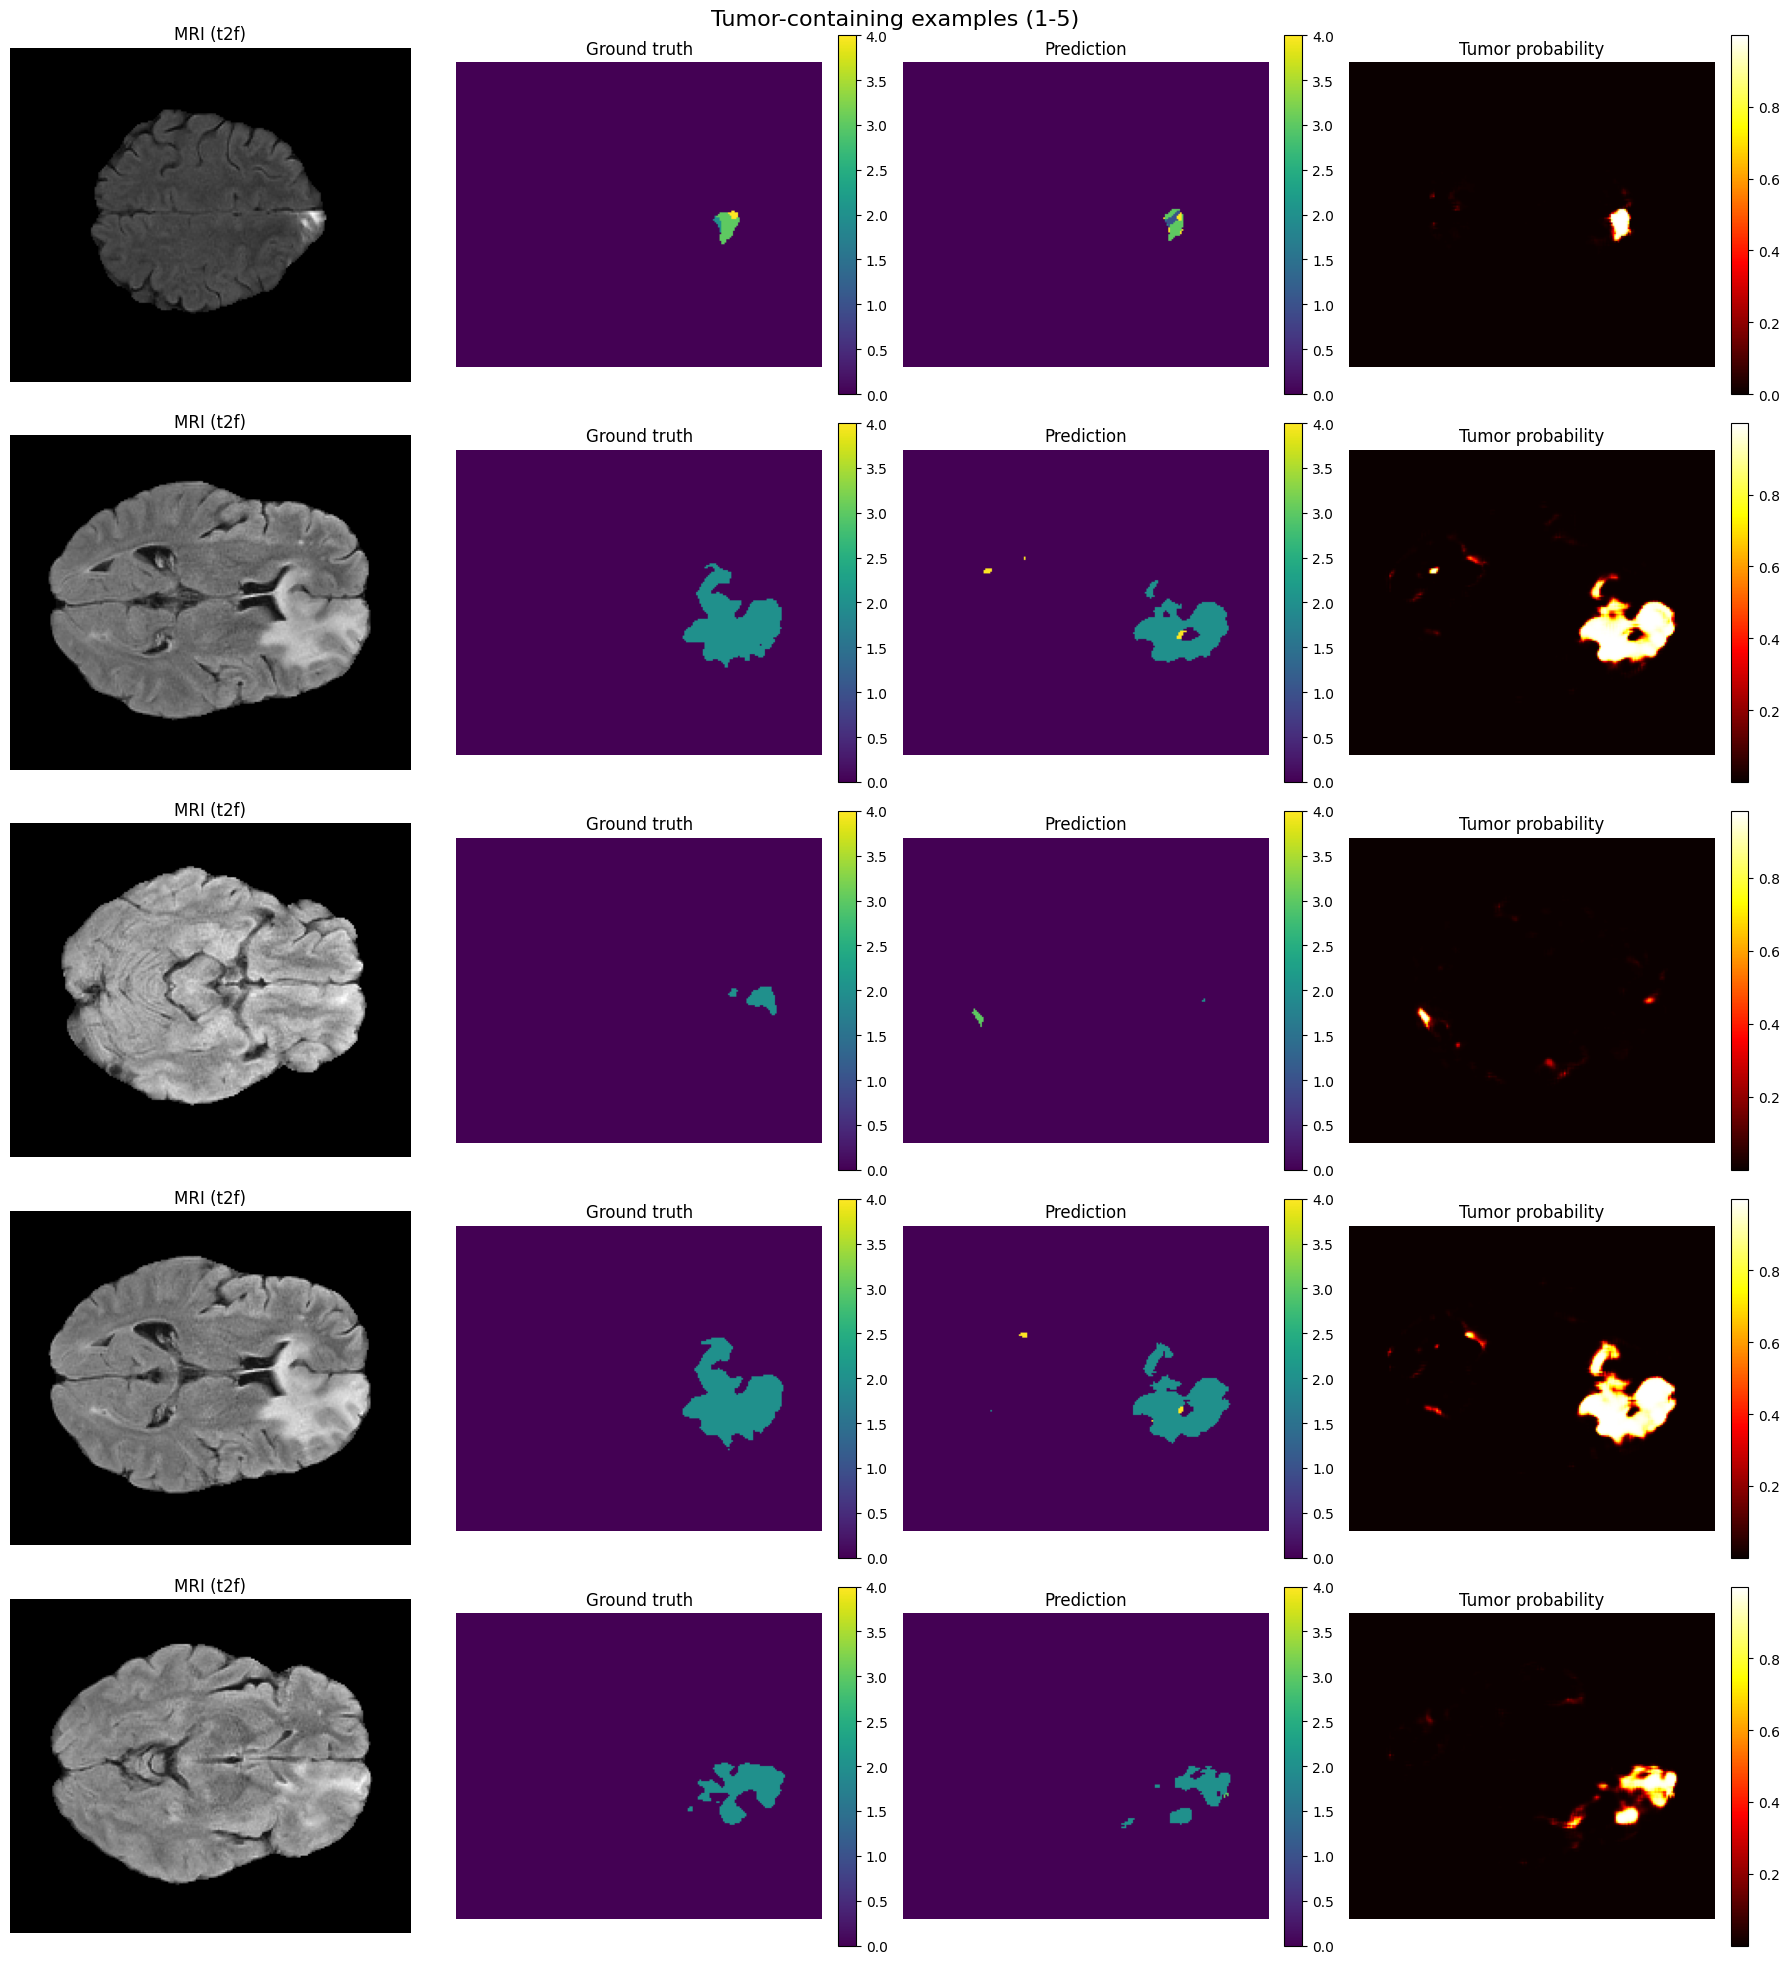

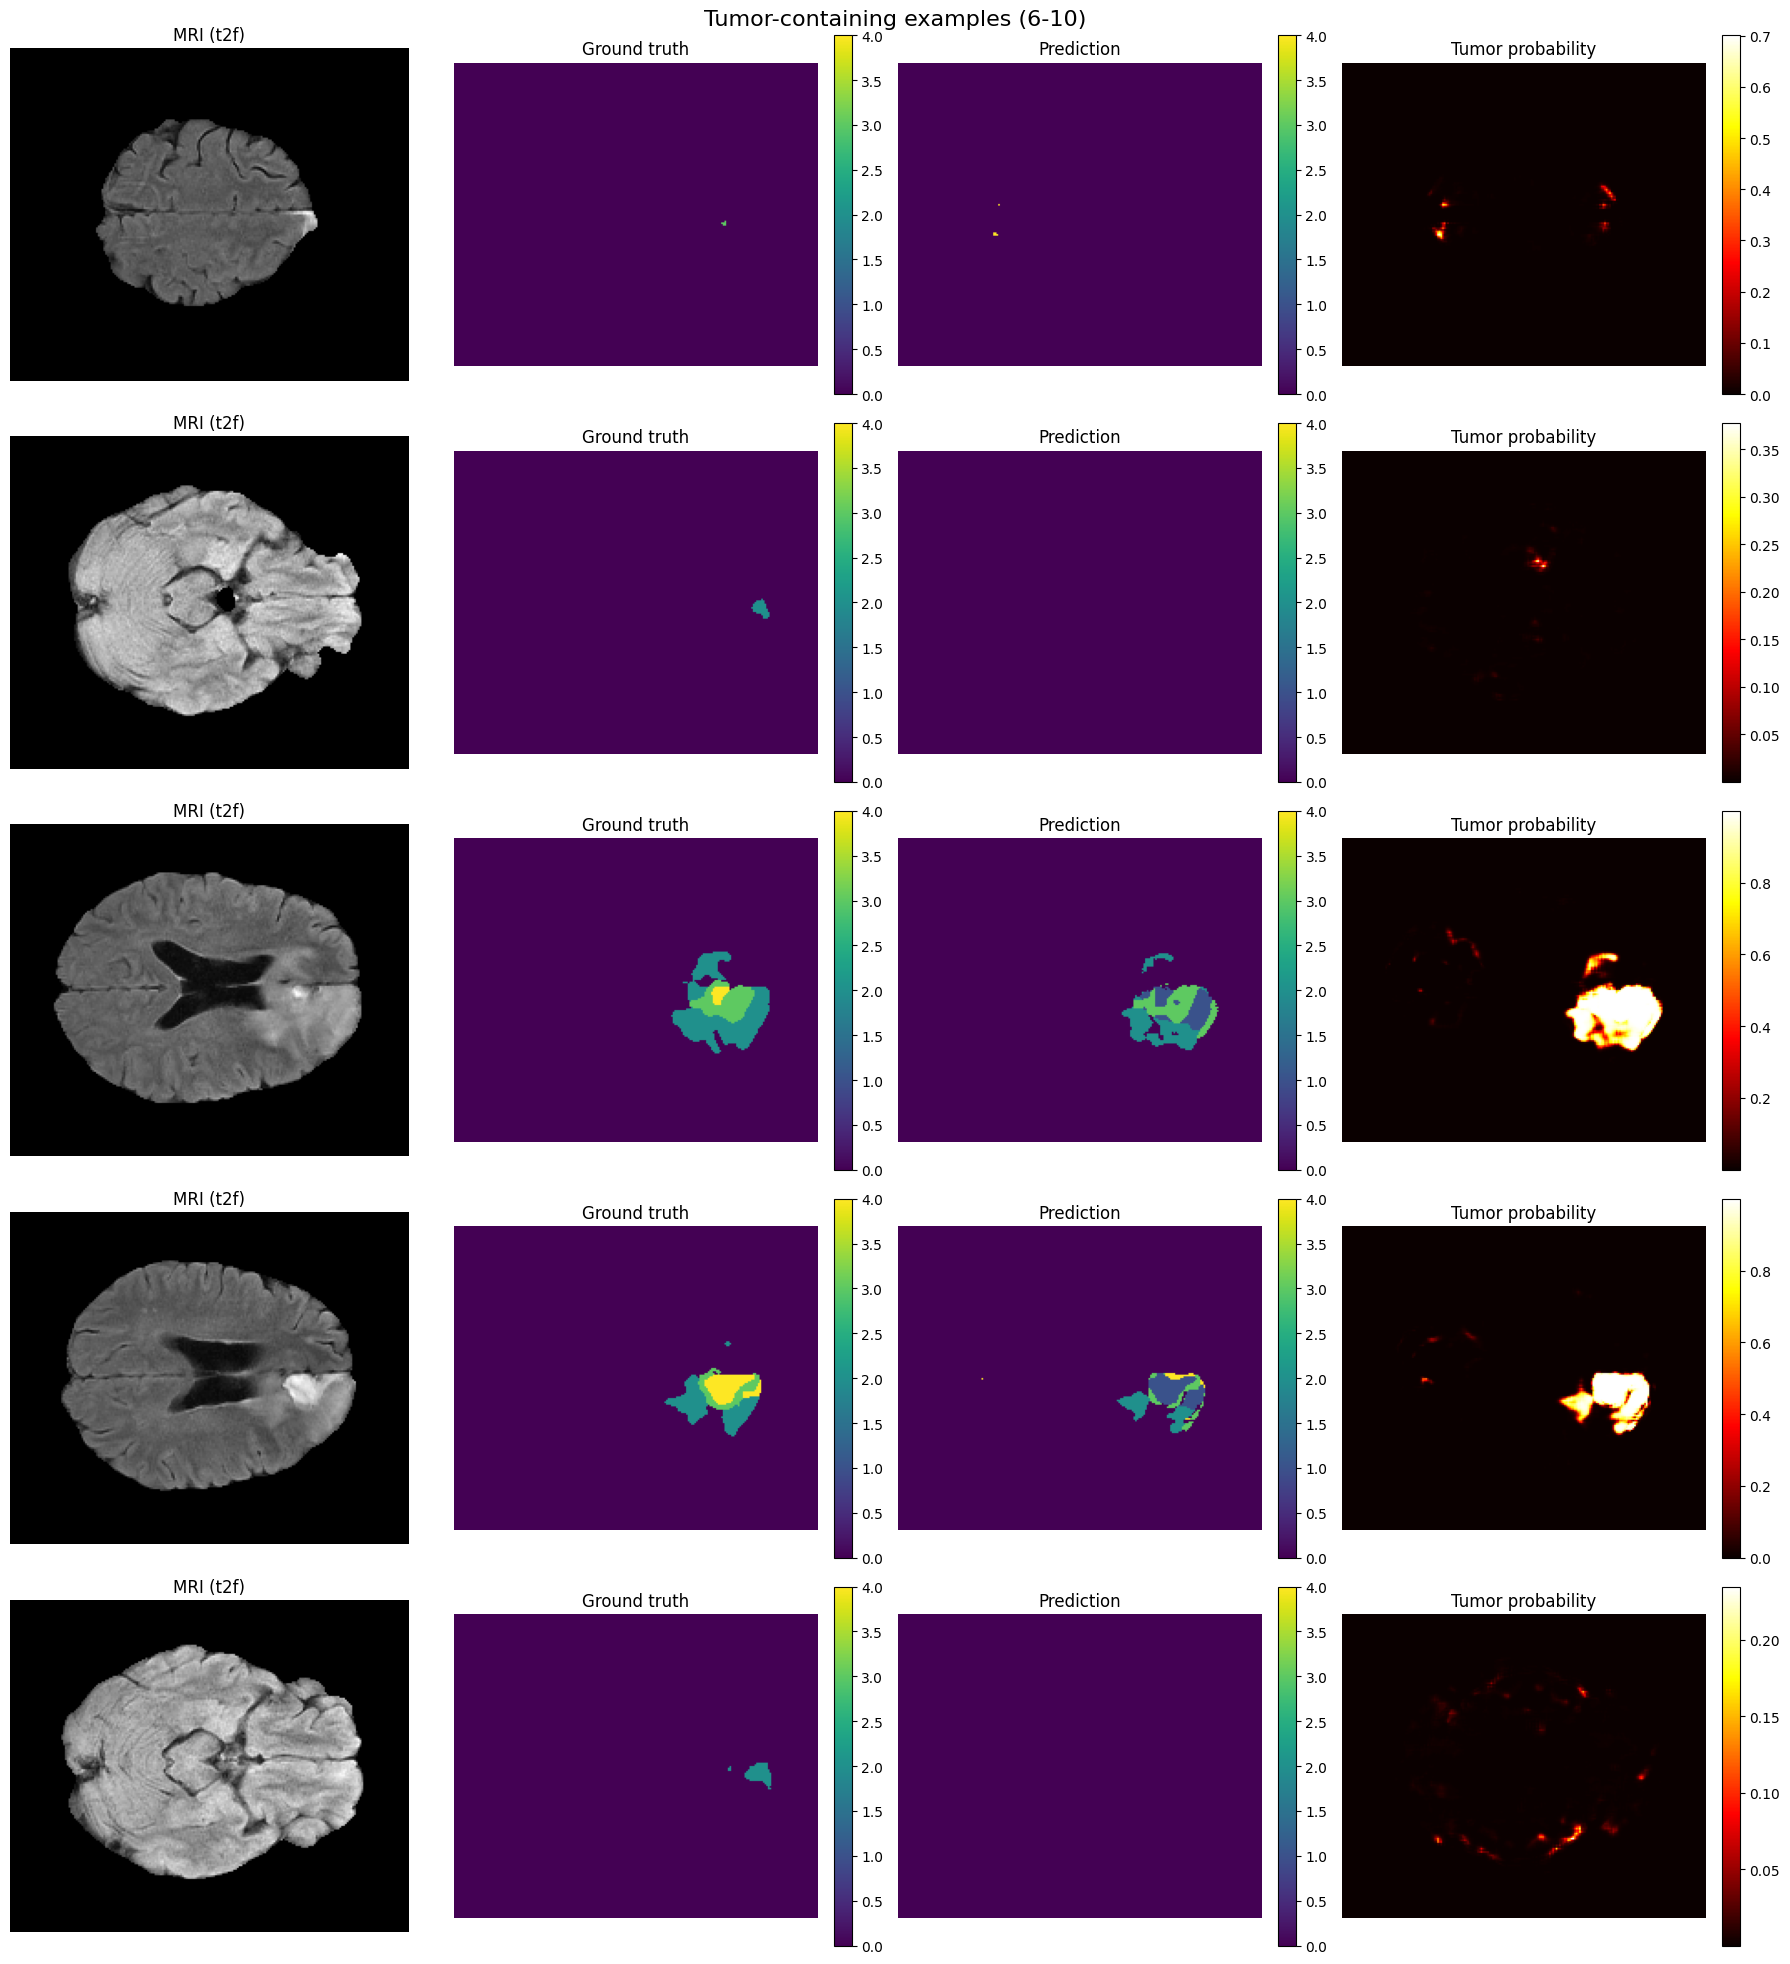

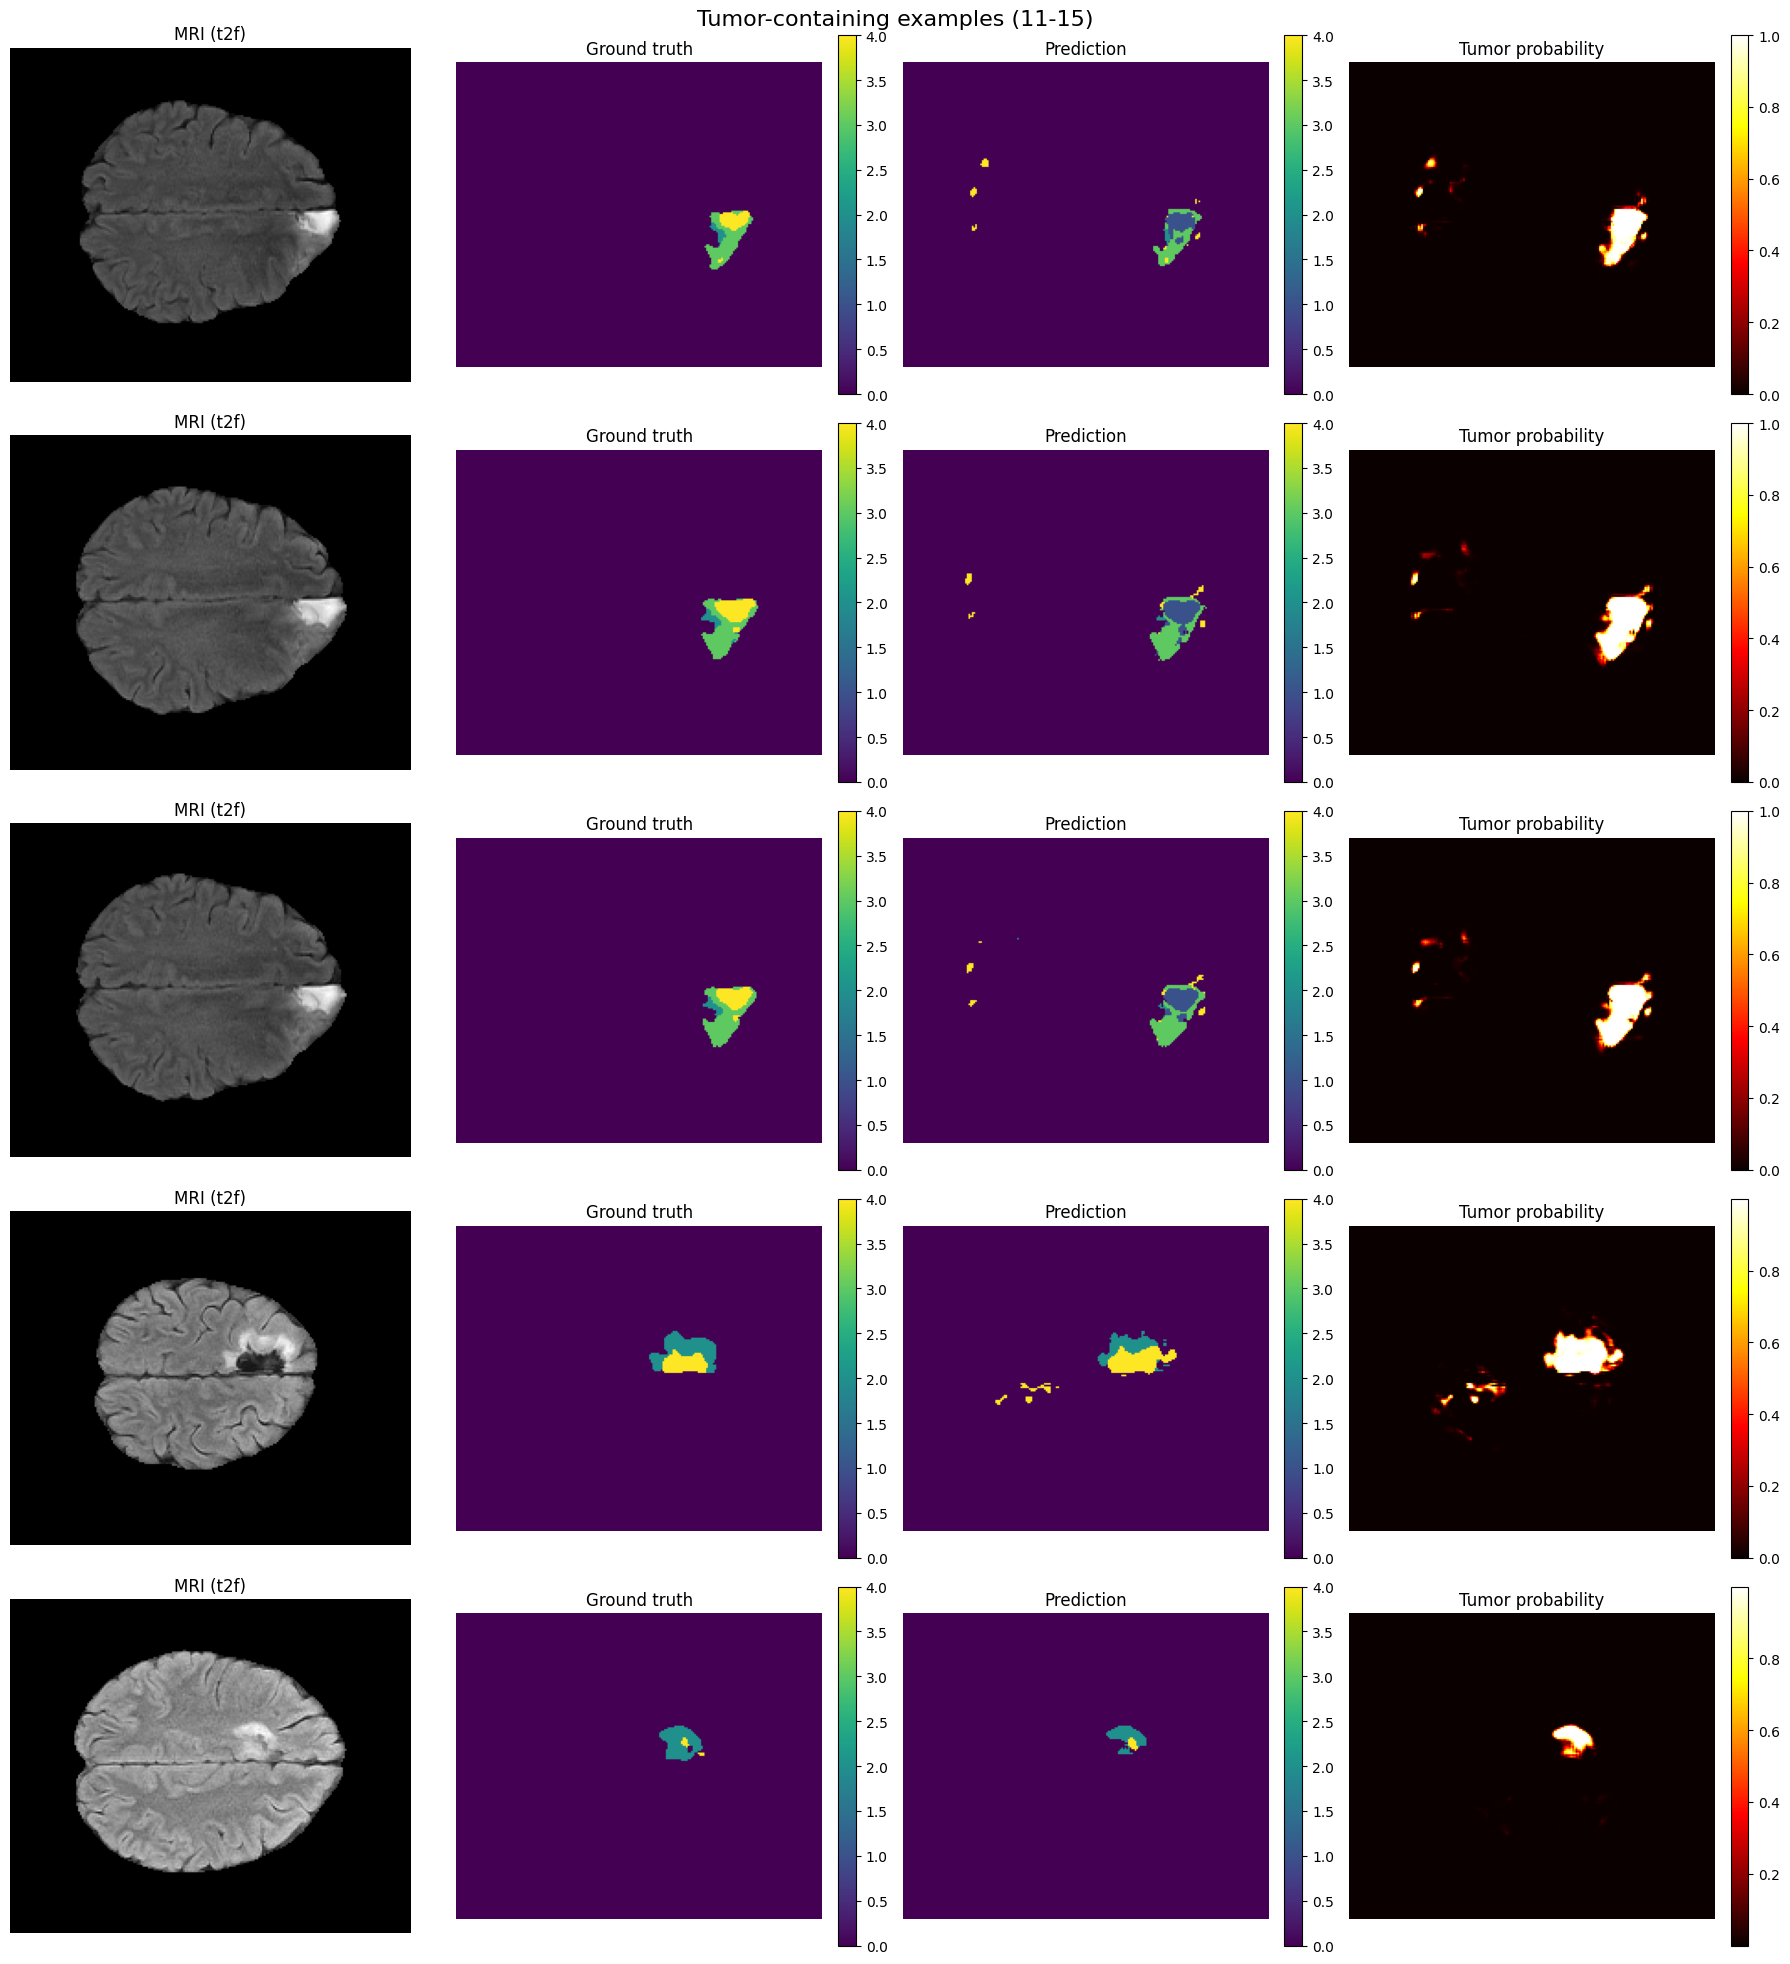

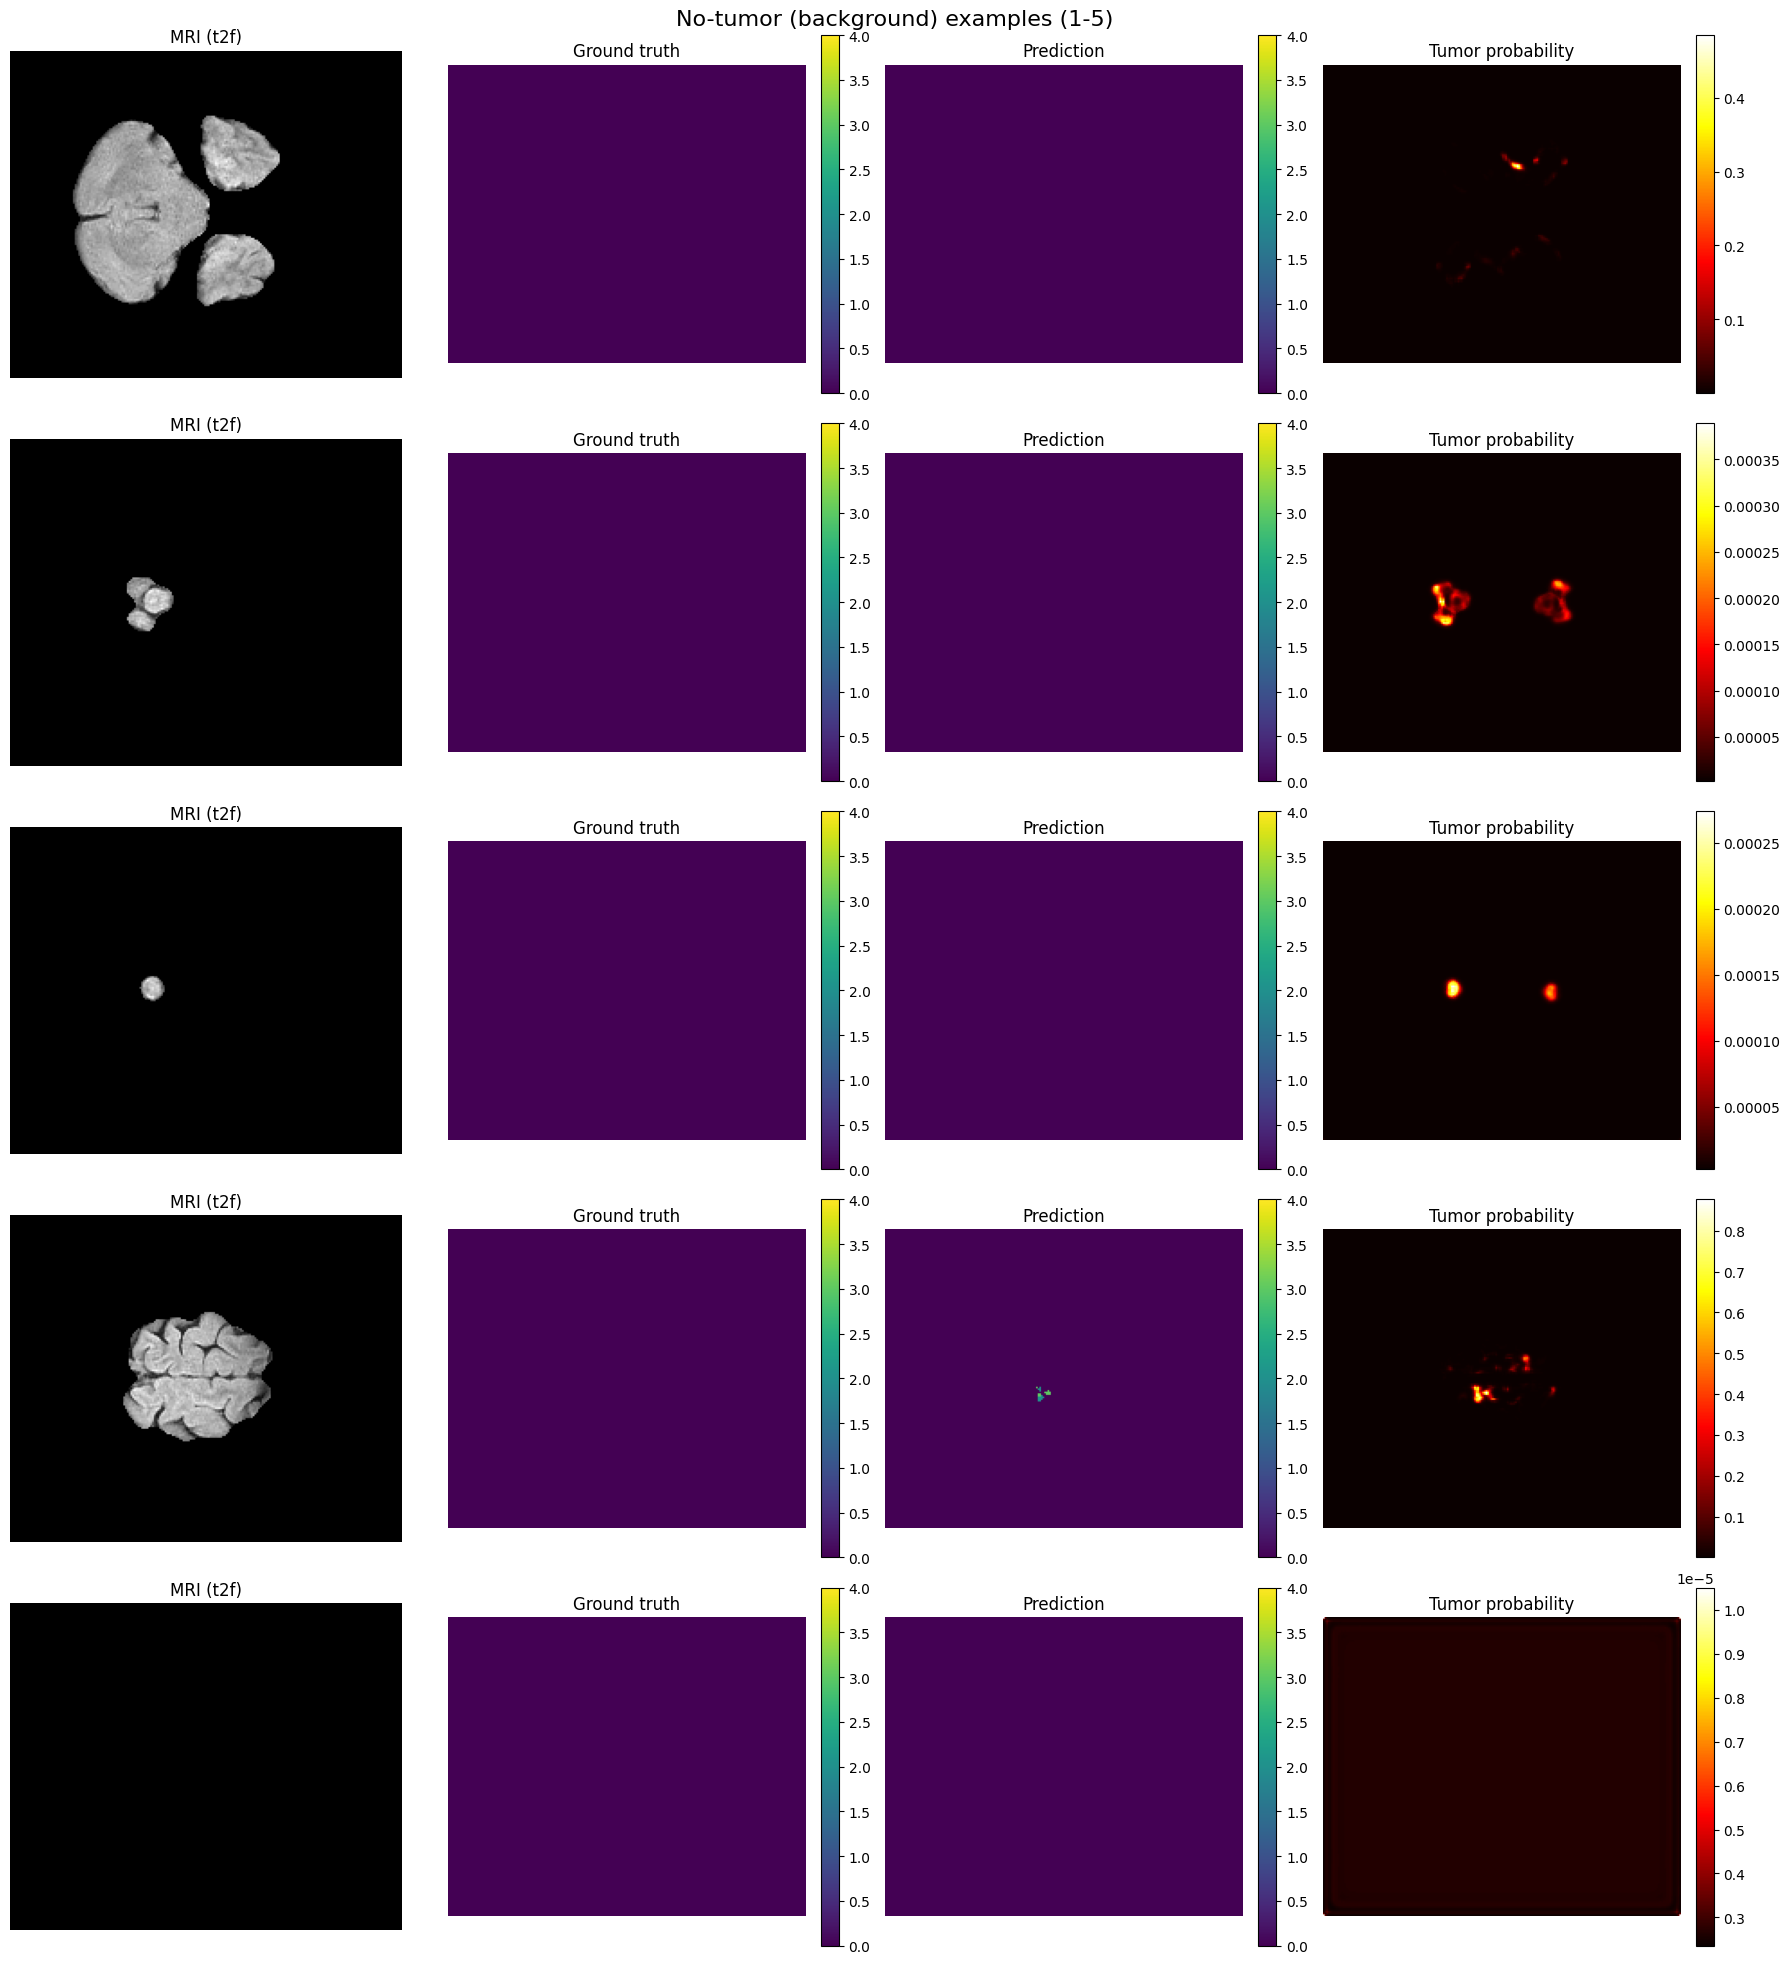

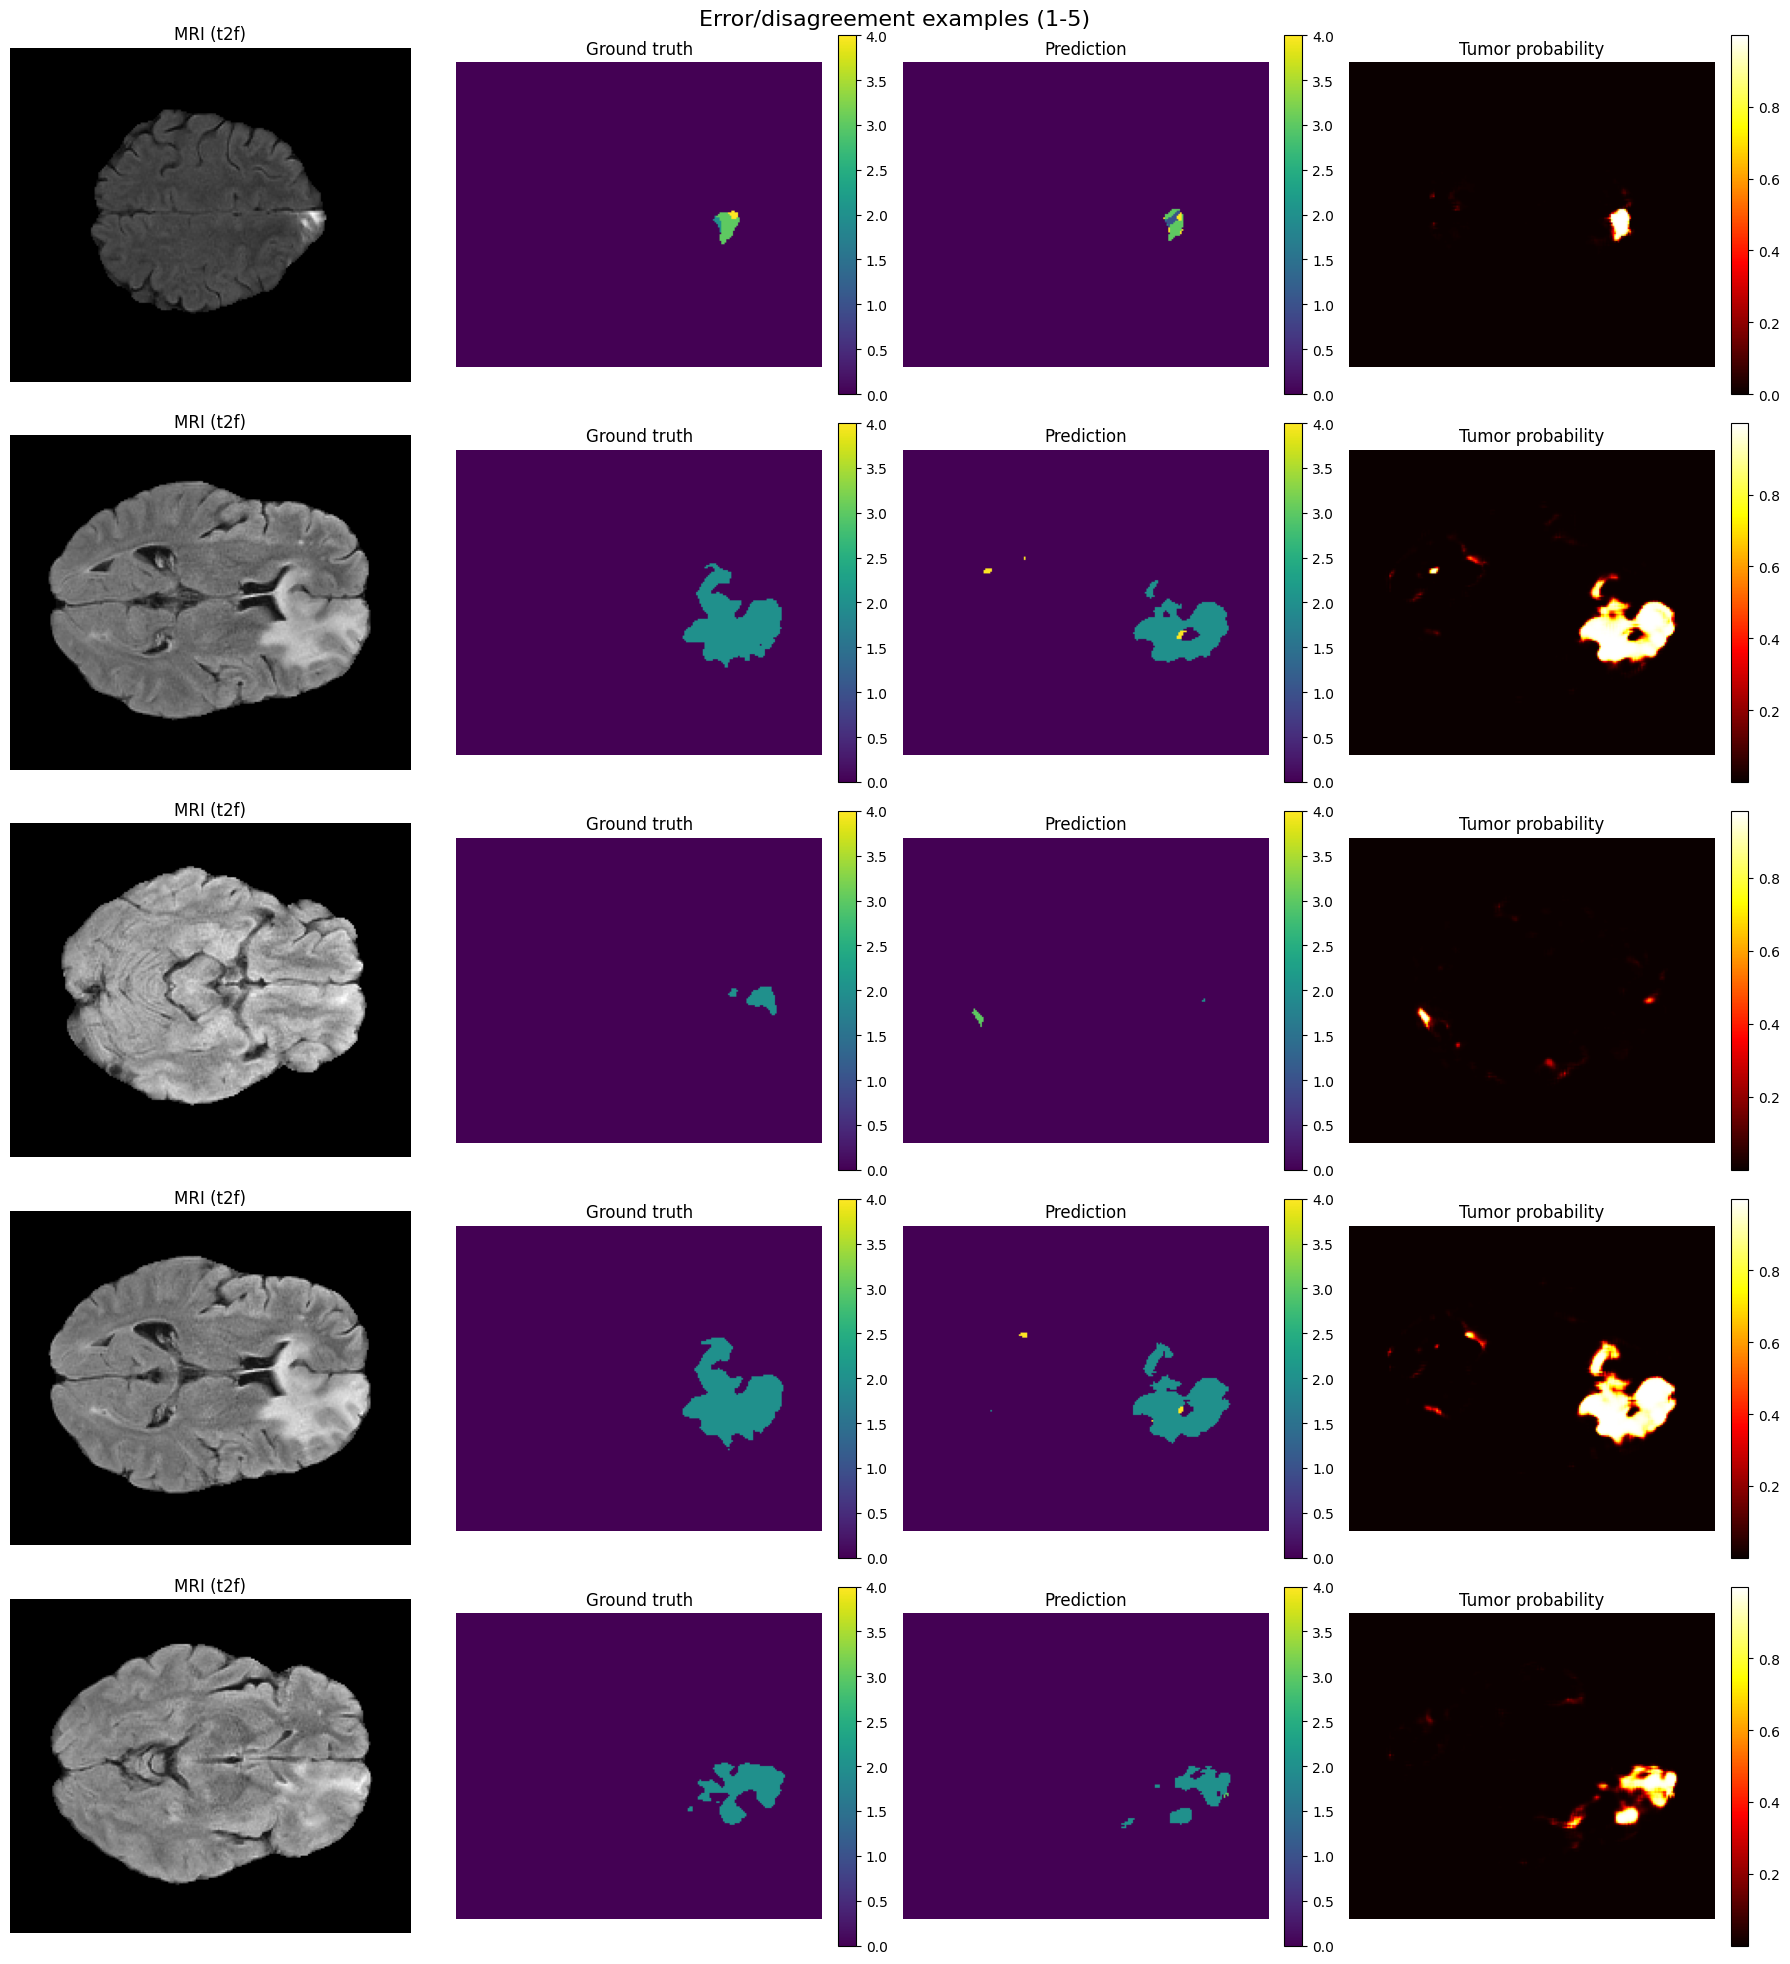

In [ ]:


model.eval()

if "t2f" in MODALITIES:
    display_ch = MODALITIES.index("t2f")
elif "t2w" in MODALITIES:
    display_ch = MODALITIES.index("t2w")
elif "t1c" in MODALITIES:
    display_ch = MODALITIES.index("t1c")
else:
    display_ch = 0

print(f"Using modality {MODALITIES[display_ch]} as background MRI.")

MAX_TUMOR_EX = 15
MAX_EMPTY_EX = 5
MAX_ERROR_EX = 5

tumor_examples = []
empty_examples = []
error_examples = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        B = images.size(0)
        for i in range(B):
            img_i   = images[i].detach().cpu().numpy()
            gt_i    = masks[i].detach().cpu().numpy()
            pred_i  = preds[i].detach().cpu().numpy()
            probs_i = probs[i]

            tumor_present = (gt_i > 0).any()
            empty_gt      = not tumor_present
            error_slice   = (gt_i != pred_i).any()

            ex = {
                "mri": img_i,
                "gt": gt_i,
                "pred": pred_i,
                "probs": probs_i,
            }

            # tumor examples
            if tumor_present and len(tumor_examples) < MAX_TUMOR_EX:
                tumor_examples.append(ex)

            # empty examples
            if empty_gt and len(empty_examples) < MAX_EMPTY_EX:
                empty_examples.append(ex)

            # error examples
            if error_slice and len(error_examples) < MAX_ERROR_EX:
                error_examples.append(ex)

        if (len(tumor_examples) >= MAX_TUMOR_EX and
            len(empty_examples) >= MAX_EMPTY_EX and
            len(error_examples) >= MAX_ERROR_EX):
            break

print(f"Collected {len(tumor_examples)} tumor slices, "
      f"{len(empty_examples)} empty slices, "
      f"{len(error_examples)} error slices.")


def plot_example_group(examples, title_prefix, max_per_fig=5):
    """
    MRI | GT | Pred | Tumor heatmap
    """
    num_ex = len(examples)
    if num_ex == 0:
        print(f"no examples for {title_prefix}.")
        return

    for start in range(0, num_ex, max_per_fig):
        end = min(start + max_per_fig, num_ex)
        group = examples[start:end]
        n = len(group)

        fig, axs = plt.subplots(n, 4, figsize=(18, 4 * n))
        if n == 1:
            axs = np.expand_dims(axs, axis=0)

        fig.suptitle(f"{title_prefix} examples ({start+1}-{end})", fontsize=16)

        for row_idx, ex in enumerate(group):
            img = ex["mri"]
            gt  = ex["gt"]
            pred = ex["pred"]
            probs_slice = ex["probs"]

            mri_slice = img[display_ch]
            tumor_probs = probs_slice[1:, ...].sum(dim=0).detach().cpu().numpy()

            # MREYE
            ax = axs[row_idx, 0]
            ax.imshow(mri_slice, cmap="gray")
            ax.set_title(f"MRI ({MODALITIES[display_ch]})")
            ax.axis("off")

            # gt
            ax = axs[row_idx, 1]
            im1 = ax.imshow(gt, vmin=0, vmax=NUM_CLASSES - 1)
            ax.set_title("Ground truth")
            ax.axis("off")
            fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

            # braindiction
            ax = axs[row_idx, 2]
            im2 = ax.imshow(pred, vmin=0, vmax=NUM_CLASSES - 1)
            ax.set_title("Prediction")
            ax.axis("off")
            fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

            # heatmappingn
            ax = axs[row_idx, 3]
            im3 = ax.imshow(tumor_probs, cmap="hot")
            ax.set_title("Tumor probability")
            ax.axis("off")
            fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()


plot_example_group(tumor_examples, "Tumor-containing")
plot_example_group(empty_examples, "No-tumor (background)")
plot_example_group(error_examples, "Error/disagreement")
